Introduction to Python Imaging Library(PIL)

Exercise-1




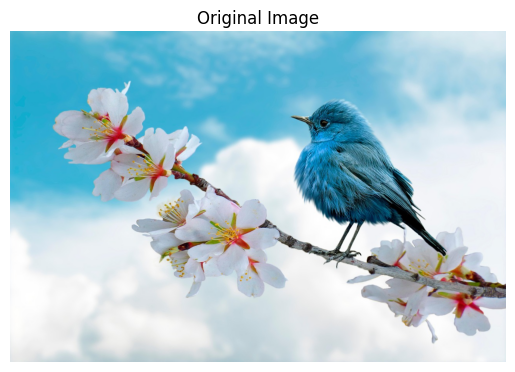

In [ ]:
#Step 1: Read and display the image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Read the image
image = Image.open("/content/drive/MyDrive/AI and ML/bird-8788491_1280.jpg")

# Display using PIL
image.show()

# Display using matplotlib
plt.imshow(image)
plt.axis('off')
plt.title("Original Image")
plt.show()

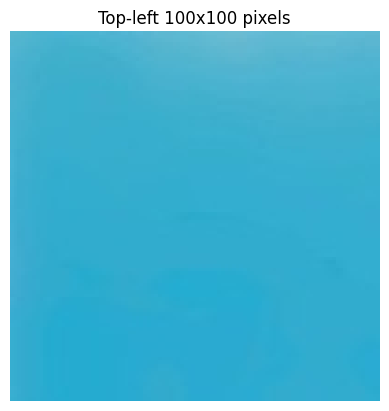

In [ ]:
#Step 2: Display top-left corner (100x100 pixels)
# Convert image to NumPy array
image_np = np.array(image)

# Extract top-left 100x100 pixels
top_left = image_np[:100, :100, :]

# Display top-left corner
plt.imshow(top_left)
plt.axis('off')
plt.title("Top-left 100x100 pixels")
plt.show()

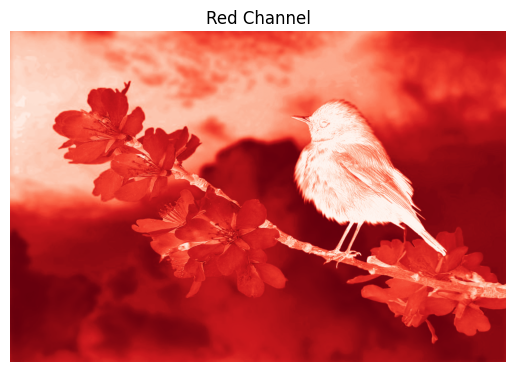

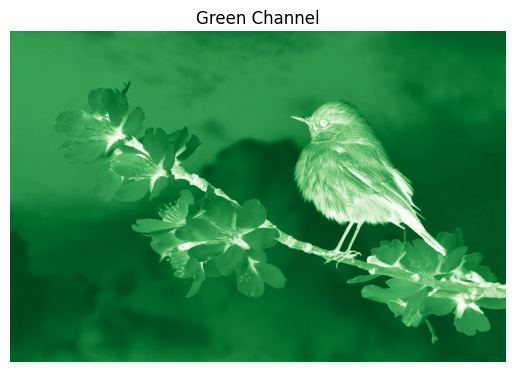

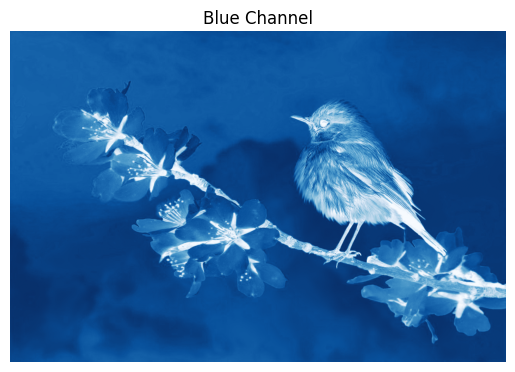

In [ ]:
#Step 3: Show the three color channels (R, G, B)
# Separate channels
R = image_np[:, :, 0]
G = image_np[:, :, 1]
B = image_np[:, :, 2]

# Display Red channel
plt.imshow(R, cmap='Reds')
plt.axis('off')
plt.title("Red Channel")
plt.show()

# Display Green channel
plt.imshow(G, cmap='Greens')
plt.axis('off')
plt.title("Green Channel")
plt.show()

# Display Blue channel
plt.imshow(B, cmap='Blues')
plt.axis('off')
plt.title("Blue Channel")
plt.show()

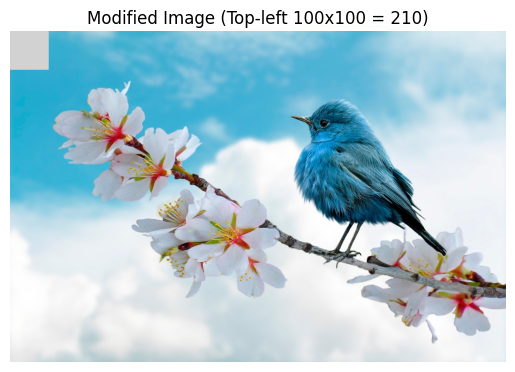

In [ ]:
#Step 4: Modify top-left 100x100 pixels to 210
# Make a copy to modify
modified_image_np = image_np.copy()

# Set top-left 100x100 pixels to 210 (light gray)
modified_image_np[:100, :100, :] = 210

# Convert back to PIL Image
modified_image = Image.fromarray(modified_image_np)

# Display the modified image
plt.imshow(modified_image)
plt.axis('off')
plt.title("Modified Image (Top-left 100x100 = 210)")
plt.show()

Exercise-2

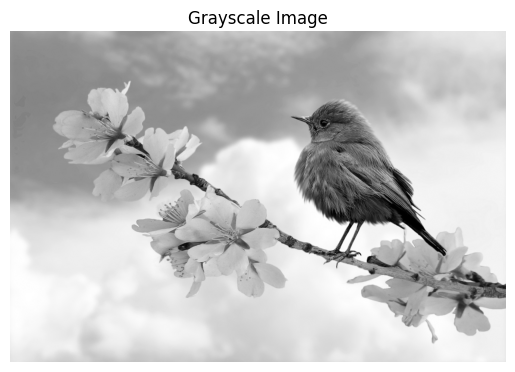

In [ ]:
#Step 1: Load and display a grayscale image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load the image in grayscale
gray_image = Image.open("/content/drive/MyDrive/AI and ML/bird-8788491_1280.jpg").convert("L")

# Display using matplotlib
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.title("Grayscale Image")
plt.show()

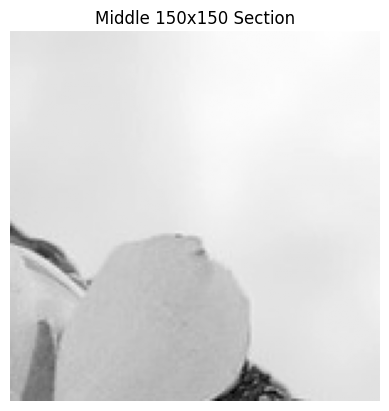

In [ ]:
#Step 2: Extract and display the middle 150x150 section
# Convert to NumPy array
gray_np = np.array(gray_image)

# Find image center
height, width = gray_np.shape
center_y, center_x = height // 2, width // 2

# Extract 150x150 middle section
half_size = 75
middle_section = gray_np[center_y - half_size:center_y + half_size,
                         center_x - half_size:center_x + half_size]

# Display middle section
plt.imshow(middle_section, cmap='gray')
plt.axis('off')
plt.title("Middle 150x150 Section")
plt.show()

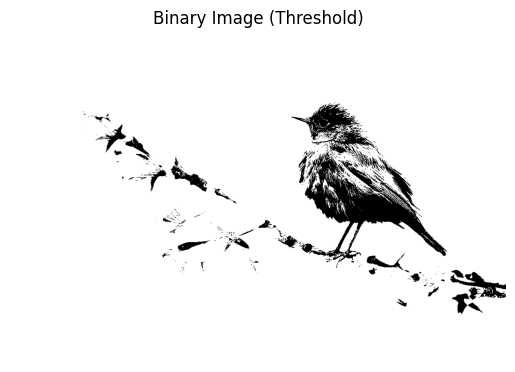

In [ ]:
#Step 3: Apply a simple threshold
# Apply threshold
binary_image = np.where(gray_np < 100, 0, 255).astype(np.uint8)

# Display binary image
plt.imshow(binary_image, cmap='gray')
plt.axis('off')
plt.title("Binary Image (Threshold)")
plt.show()

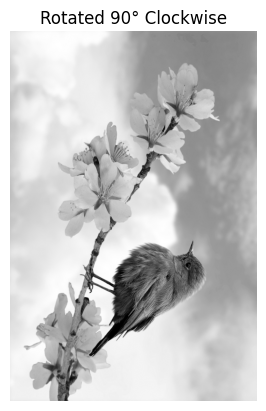

In [ ]:
#Step 4: Rotate the image 90 degrees clockwise
#Using Pillow rotate
rotated_image = gray_image.rotate(-90, expand=True)

# Display rotated image
plt.imshow(rotated_image, cmap='gray')
plt.axis('off')
plt.title("Rotated 90° Clockwise")
plt.show()

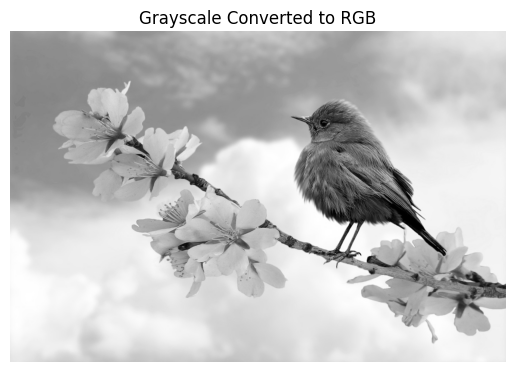

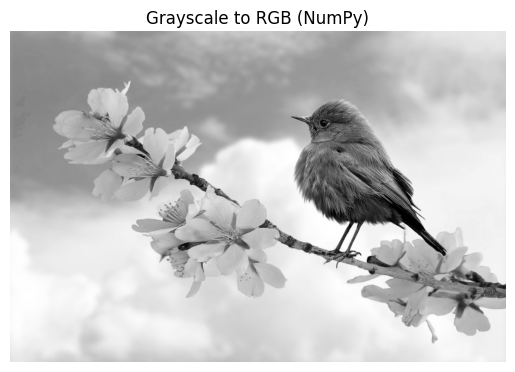

In [ ]:
#Step 5: Convert grayscale image to RGB
# Using PIL
rgb_image = gray_image.convert("RGB")

# Display RGB image
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Grayscale Converted to RGB")
plt.show()

# Using NumPy
rgb_np = np.stack((gray_np,)*3, axis=-1)
plt.imshow(rgb_np)
plt.axis('off')
plt.title("Grayscale to RGB (NumPy)")
plt.show()

Image Compression and Decompression using PCA.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load and Prepare Data

# Load image and convert to grayscale
image = Image.open("/content/drive/MyDrive/AI and ML/bird-8788491_1280.jpg").convert("L")
image_array = np.array(image, dtype=np.float64)

# Original image shape
height, width = image_array.shape
data = image_array

# Center the dataset
mean = np.mean(data, axis=0)
centered_data = data - mean

# Covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

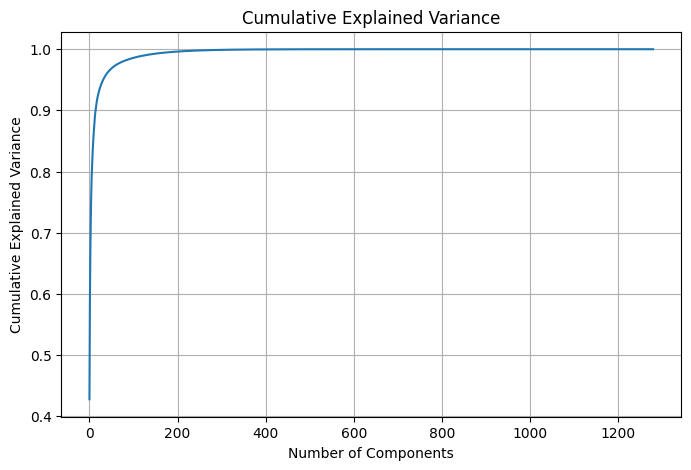

In [13]:
# 2. Eigen Decomposition and Identify Principal Components

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Cumulative explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [14]:
# 3. Reconstruction using k components

k = 50
components = eigenvectors[:, :k]

# Compress the image
compressed_data = np.dot(centered_data, components)

# Decompress / reconstruct the image
decompressed_data = np.dot(compressed_data, components.T) + mean

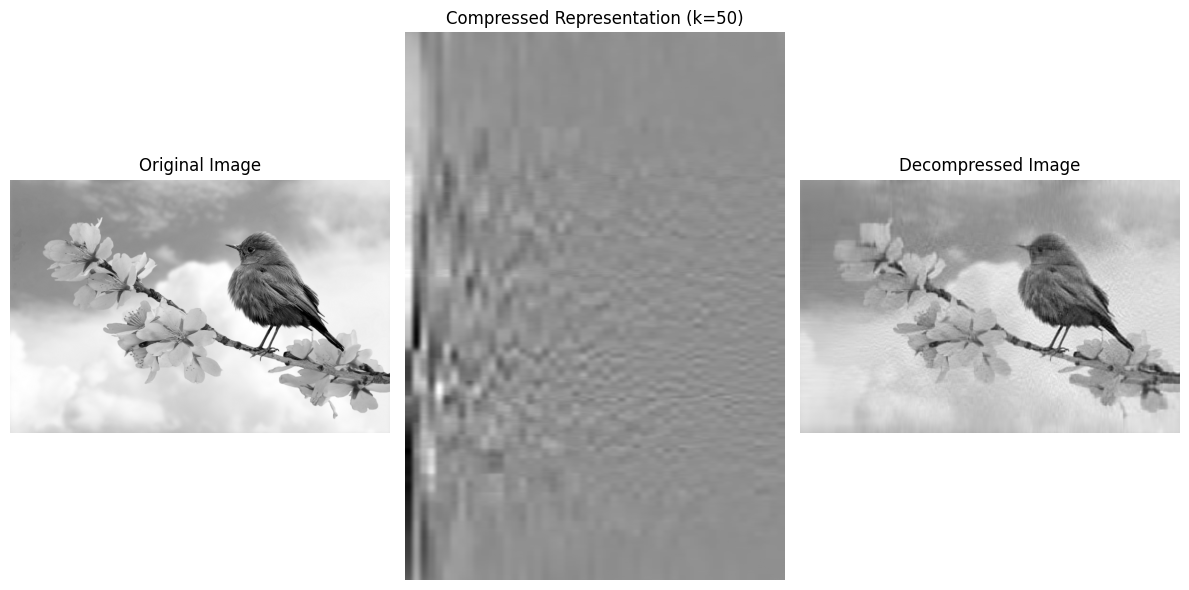

In [15]:
# 4. Display Results

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Compressed Representation
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title(f"Compressed Representation (k={k})")
plt.axis("off")

# Decompressed Image
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

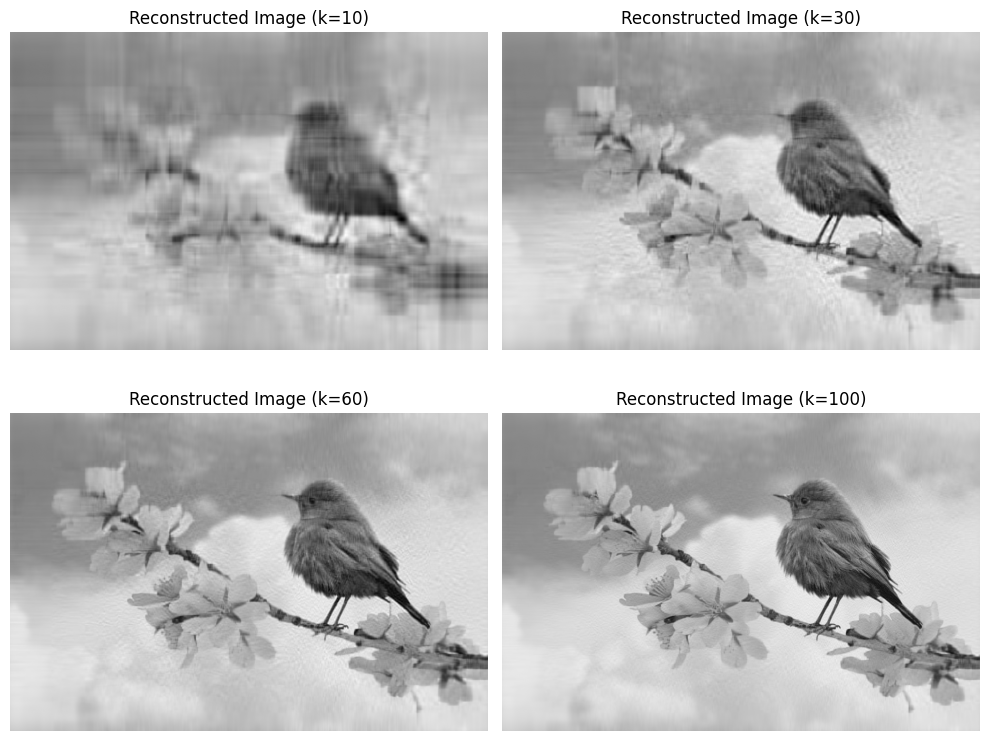

In [17]:
#5. Reconstruct Image

k_values = [10, 30, 60, 100]

plt.figure(figsize=(10, 8))

for i, k in enumerate(k_values):
    components = eigenvectors[:, :k]
    compressed_data = np.dot(centered_data, components)
    decompressed_data = np.dot(compressed_data, components.T) + mean

    plt.subplot(2, 2, i + 1)
    plt.imshow(decompressed_data, cmap="gray")
    plt.title(f"Reconstructed Image (k={k})")
    plt.axis("off")

plt.tight_layout()
plt.show()